In [101]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_algebra import QR_dec, determinant





# --------------------------------------------

# plt.rcParams.update({
#     "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
#     "font.family": "serif",        # Usa un font Serif per il testo normale
#     "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
#     "axes.labelsize": 16,          # Dimensione font etichette assi
#     "font.size": 14,                # Dimensione font generale
#     "legend.fontsize": 14,         # Dimensione font legenda
#     "xtick.labelsize": 13,         # Dimensione numeri asse x
#     "ytick.labelsize": 13,         # Dimensione numeri asse y
#     "figure.figsize": (8, 6),      # Dimensione predefinita della figura
#     "figure.dpi": 100,             # Risoluzione
    
#     "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
# })

# --------------------------------------------


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
A_test = np.array([[2.,1],[1,3]])

def Power_mth(A_in, epsilon=1e-14, N_max=100000):
    A = np.copy(A_in)
    x_0 = np.random.rand(len(A))    # choice of a random vector
    y = x_0 / np.sqrt(x_0@x_0)      # the vector is chosen normalised
    lamb1 = 1
    lambt = 0

    for i in range(N_max):
        if abs(lamb1 - lambt) > epsilon:
            y = A @ y
            y = y / np.sqrt(y@y)
            lambt = lamb1
            lamb1 = y.T @ A @ y     # y is normalised --> lamb1 is the next eigval
        else:
            print(f'Iteration {i}: reached max precision\n')
            break
        
    eigVal = lamb1 
    eigVect = y
    if np.sum(A @ eigVect) - np.sum(eigVal * eigVect) > 1e-8:
        raise ValueError('Eigenvalue/vector is not accurate')

    return eigVal, eigVect

eig_val, eig_vect = Power_mth(A_test)
print('A =', A_test)
print()
print('eig_val =', eig_val)
print('eig_vect =', eig_vect)
print(f'determinant = {determinant(A_test):.1f}')



Iteration 18: reached max precision

A = [[2. 1.]
 [1. 3.]]

eig_val = 3.618033988749894
eig_vect = [0.52573113 0.8506508 ]
determinant = 5.0


Iteration 35: reached max precision

Iteration 162: reached max precision



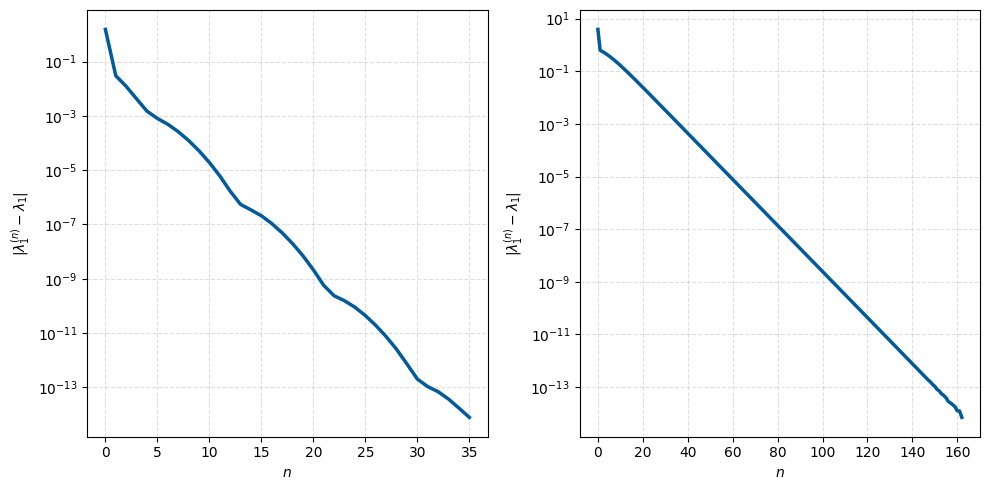

In [103]:

A_real = np.random.rand(3,3)
A_compl = np.array([
    [4,   -1j,        2],
    [1j,   2,   2 + 7j],
    [2,  2 - 7j,     -2]
], dtype=complex)

def plot_convergence(A_in):
    N_max = 100000
    epsilon = 1e-14
    A = np.copy(A_in)
    
    errors = []
    x_0 = np.random.rand(len(A)) + 1j*np.random.rand(len(A))
    y = x_0 / np.sqrt(np.real(x_0.T.conj() @ x_0))      # choice of a random vector
    
    lamb_old = 0.0

    for i in range(N_max):
        y = A @ y                       
        y = y / np.sqrt(np.real(y.T.conj() @ y))    # the vector is chosen normalised
        
        # Rayleigh Quotient
        lamb_new = y.T.conj() @ A @ y    # y is normalised --> lamb1 is the next eigval
        
        # error respect to the previous step
        err = abs(lamb_new - lamb_old)
        errors.append(err)
        
        if err < epsilon:
            print(f'Iteration {i}: reached max precision\n')
            break
        
        lamb_old = lamb_new

    return np.array([np.arange(len(errors)), errors])




out_real = plot_convergence(A_real)
out_comp = plot_convergence(A_compl)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# plt.title(r'Convergenza di \textbf{Power Method}')

ax[0].plot(out_real[0], out_real[1], color='#005a9c', linewidth=2.5)
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$n$')
ax[0].set_ylabel(r'$|\lambda_1^{(n)} - \lambda_1|$')
ax[0].grid(alpha=0.4, ls='--')

ax[1].plot(out_comp[0], out_comp[1], color='#005a9c', linewidth=2.5)
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$n$')
ax[1].set_ylabel(r'$|\lambda_1^{(n)} - \lambda_1|$')
ax[1].grid(alpha=0.4, ls='--')
plt.tight_layout()
plt.show()



## **Matrice complessa**

In [104]:
A_test = np.array([
    [4,   -1j,        2],
    [1j,   2,   2 + 7j],
    [2,  2 - 7j,     -2]
], dtype=complex)

eig_val, eig_vect = Power_mth(A_test)
diff = A_test@eig_vect - eig_val*eig_vect
print('A =', A_test)
print()
print('eig_val =', eig_val)
print('eig_vect =', eig_vect)


Iteration 357: reached max precision

A = [[ 4.+0.j -0.-1.j  2.+0.j]
 [ 0.+1.j  2.+0.j  2.+7.j]
 [ 2.+0.j  2.-7.j -2.+0.j]]

eig_val = (8.451876899596733-5.329070518200751e-15j)
eig_vect = [0.63491092-0.59342626j 1.18122253+0.91110263j 0.95772132-0.73031907j]
